# GBDTE Poisson Mode — Demo

This notebook shows how to work with `PoissonLegacyBooster`: the data contract, the
basic (constant-rate) mode, the extra mode with a time-varying intensity, and the
synthetic benchmark with baseline comparison.

Background and math: [`docs/poisson_mode/README.md`](../../docs/poisson_mode/README.md)
and [`docs/poisson_mode/poisson_mode_explained.pdf`](../../docs/poisson_mode/poisson_mode_explained.pdf).

**Engine constraints** (validated by `python/tests/test_poisson_semantics.py`):
use `n_stages=1` in extra mode (multi-stage has a known unit-mismatch bug), and keep
all counts strictly positive (zero counts crash the CGO layer).

In [1]:
import sys
sys.path.insert(0, "../../python")   # run from notebooks/poisson_mode/

import numpy as np
import matplotlib.pyplot as plt

from extra_boost_py import PoissonLegacyBooster, PoissonLegacyParams

rng = np.random.default_rng(0)

## 1. Basic mode: constant rates per leaf

Without `features_extra` the booster is an ordinary Poisson tree: each leaf predicts a
constant expected count. One row per object: `bjids`, `freqs` (counts), and partition
features.

In [2]:
n = 400
group = rng.integers(0, 2, n)
freqs = rng.poisson(np.where(group == 0, 10.0, 30.0)).astype(np.float64)

booster = PoissonLegacyBooster.train(
    bjids=np.arange(n, dtype=np.int32),
    freqs=freqs,
    features_inter=group.reshape(-1, 1).astype(np.float64),
    params=PoissonLegacyParams(n_stages=1, max_depth=1, learning_rate=1.0),
)
preds = booster.predict(np.array([[0.0], [1.0]]))
print(f"leaf predictions: {preds.round(2)}")
print(f"group means:      [{freqs[group == 0].mean():.2f} {freqs[group == 1].mean():.2f}]")

leaf predictions: [10.36 30.02]
group means:      [10.36 30.02]


## 2. Extra mode: time-varying intensity in the leaves

Now each object is a **cohort** observed over the window $[0, 1]$ in `n_bins` time
bins; each row is (object, bin, count). The leaf model is $\lambda(t) = w^\top (1, t)$
and `psi` $= \int_0^1 (1, t)\,dt = (1, 0.5)$ carries the exposure term.

Two latent groups with opposite trends: $\lambda_0(t) = 2 + 2t$ (rising) and
$\lambda_1(t) = 4 - 2t$ (falling).

In [3]:
n_obj, n_bins, exposure = 200, 10, 20
edges = np.linspace(0.0, 1.0, n_bins + 1)
centers = (edges[:-1] + edges[1:]) / 2
delta = edges[1] - edges[0]

rows = []
for j in range(n_obj):
    g = j % 2
    lam = 2 + 2 * centers if g == 0 else 4 - 2 * centers
    counts = np.maximum(rng.poisson(lam * delta * exposure), 1)  # counts must stay > 0
    rows += [(j, counts[b], float(g), centers[b]) for b in range(n_bins)]
arr = np.array(rows)

booster = PoissonLegacyBooster.train(
    bjids=arr[:, 0].astype(np.int32),
    freqs=arr[:, 1],
    features_inter=arr[:, 2].reshape(-1, 1),
    features_extra=np.column_stack([np.ones(len(arr)), arr[:, 3]]),
    psi=np.array([1.0, 0.5]),
    params=PoissonLegacyParams(n_stages=1, max_depth=3, learning_rate=1.0),
)

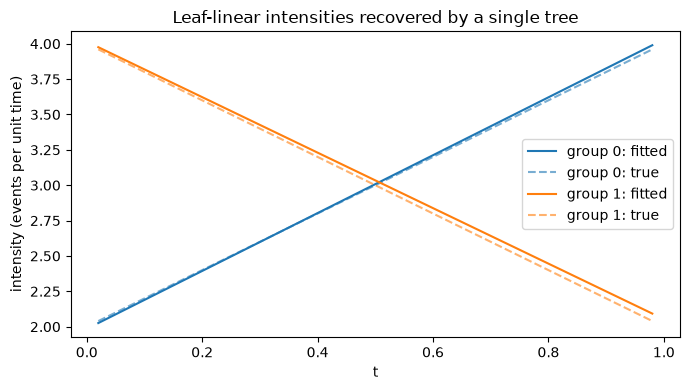

In [4]:
t_grid = np.linspace(0.02, 0.98, 50)
phi = np.column_stack([np.ones_like(t_grid), t_grid])

fig, ax = plt.subplots(figsize=(7, 4))
for g, style, true_fn in [(0.0, "C0", lambda t: 2 + 2 * t), (1.0, "C1", lambda t: 4 - 2 * t)]:
    pred_rate = booster.predict(np.full((len(t_grid), 1), g), phi) / (exposure * delta)
    ax.plot(t_grid, pred_rate, style, label=f"group {int(g)}: fitted")
    ax.plot(t_grid, true_fn(t_grid), style + "--", alpha=0.6, label=f"group {int(g)}: true")
ax.set_xlabel("t")
ax.set_ylabel("intensity (events per unit time)")
ax.legend()
ax.set_title("Leaf-linear intensities recovered by a single tree")
plt.tight_layout()
plt.show()

The single tree splits on the group feature and each leaf recovers its linear
intensity — including the *trend*, which is what a constant-leaf Poisson booster cannot
carry into an unseen time window.

Note the unit convention: predictions are per-bin expected **counts** of the cohort, so
we divide by `exposure * delta` to plot the per-unit rate.

## 3. The synthetic benchmark and baselines

`poisson_bench.py` generalizes this toy into the "grouped drifting intensity" benchmark
(latent groups, role-purity and drift knobs, temporal train/test split at $t=0.6$, and
a `lam_true` oracle column). The wrappers in `poisson_baselines.py` give every model the
same interface.

In [5]:
from extra_boost_py.experiments.poisson_bench import PoissonBenchConfig, generate_poisson
from extra_boost_py.experiments.poisson_baselines import make_poisson_models
from extra_boost_py.experiments.stats import evaluate

bench = generate_poisson(PoissonBenchConfig(k_groups=8, n_objects=500, seed=0))
models = make_poisson_models()

results = {}
for name in ["gbdte_pois", "gbdte_pois_const", "lgbm_pois", "oracle_pois"]:
    model = models[name]
    if not model.available():
        continue
    model.fit(bench, {"max_depth": 4} if name == "gbdte_pois" else None)
    results[name] = evaluate(model, bench)

for name, res in sorted(results.items(), key=lambda kv: kv[1]["poisson_dev"]):
    print(f"{name:18s} deviance={res['poisson_dev']:.3f}  rate_rmse={res['rate_rmse']:.2f}")

oracle_pois        deviance=0.879  rate_rmse=0.00
lgbm_pois          deviance=0.985  rate_rmse=12.63
gbdte_pois_const   deviance=1.114  rate_rmse=18.09
gbdte_pois         deviance=1.535  rate_rmse=13.24


/home/tarstars/prj/extra_bridged_boosting/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Interpretation: `oracle_pois` is the Bayes bound (it knows the true intensity).
The engine's single-stage restriction currently handicaps `gbdte_pois` relative to
boosted baselines such as LightGBM — the full 10-seed comparison with statistics lives
in `reports/article_experiments/baselines_poisson/` and reruns via:

```bash
PYTHONPATH=python .venv/bin/python scripts/run_article_experiments.py \
    --suite baselines_poisson --seeds 10
```

## 4. Pitfalls checklist

1. **`n_stages=1` only** (extra mode) until the multi-stage unit-mismatch bug in
   `wholeLossNextTreeExtra` is fixed — the strict `xfail` test in
   `test_poisson_semantics.py` will flip when it is.
2. **No zero counts** — aggregate bins/cohorts so every `freqs` entry is ≥ 1.
3. **Units**: predictions are per-bin counts; divide by `exposure * delta` for rates.
4. **Extrapolated leaf intensities can approach zero** far outside the training window;
   clip and sanity-check before using them in a deviance.